# Setup and Configs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from feature_visualization import FeatureAnalyzer
from dotenv import load_dotenv
from pathlib import Path

In [2]:
# -- Configs -- #
expansion_factor = 4
_lambda = 1e-2
gpt_dim = 768
feature_analysis_count = 25
sampling = False

project_root = Path().resolve().parent.parent
load_dotenv(project_root / ".env")

sampling_suffix = '_sampling' if sampling else ''
HF_dataset_path = f"thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x_{_lambda}{sampling_suffix}"
table_name=f"hf_{expansion_factor}x_{str(_lambda).replace(".", "_")}_full{sampling_suffix}"

feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_dataset_path,
        db_name = str(project_root / "sae_feature_activations"),
        expansion_factor = expansion_factor
    )

feature_analyzer.create_features_table(table_name = table_name)
feature_analyzer.build_vocab_table()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# Batch Feature Analysis

Filter features by selectivity (mean activation / log(num activations + 1)), take top/bottom k, then batch-analyze all of them. Results are cached so individual inspection is instant.

In [3]:
min_activations = 10

feature_selective_ranked = feature_analyzer.rank_features_by_selectivity(
    table_name=table_name,
    min_activations=min_activations
)
top_k_df = feature_selective_ranked.head(feature_analysis_count)
bottom_k_df = feature_selective_ranked.tail(feature_analysis_count)

In [4]:
def analyze_feature(feature_id: int) -> dict:
    top_act_df = feature_analyzer.get_top_activations(table_name, int(feature_id), top_k=25)
    top_act_df = feature_analyzer.reconstruct_token_text(top_act_df)
    top_act_df = feature_analyzer.reconstruct_context_text(top_act_df)

    labeled_df = feature_analyzer.label_feature(top_act_df, use_groq = False)
    llm_label = labeled_df["llm_label"].iloc[0]
    llm_reasoning = labeled_df["llm_reasoning"].iloc[0]

    stats = feature_analyzer.get_activation_distribution(table_name, int(feature_id))
    cooc = feature_analyzer.get_co_occuring_features(table_name, int(feature_id))
    breakdown = feature_analyzer.get_token_type_breakdown(int(feature_id), table_name)

    raw_activations = feature_analyzer.query(
        f"SELECT activation_value FROM {table_name} WHERE feature_id = {int(feature_id)}"
    )["activation_value"].values

    return {
        "feature_id": feature_id,
        "llm_label": llm_label,
        "llm_reasoning": llm_reasoning,
        "top_activations": labeled_df,
        "activation_stats": stats,
        "co_occurring_features": cooc,
        "token_type_breakdown": breakdown,
        "raw_activations": raw_activations,
    }

In [5]:
def display_feature_result(r: dict, show_histogram: bool = True):
    print("=" * 80)
    print(f"Feature {r['feature_id']}: {r['llm_label']}")
    if "group" in r:
        print(f"Group: {r['group']}")
    print("=" * 80)

    print(f"\n--- LLM Reasoning ---\n{r['llm_reasoning']}")

    print("\n--- Top Activations ---")
    display(r["top_activations"])

    print("\n--- Activation Distribution Stats ---")
    for k, v in r["activation_stats"].items():
        print(f"  {k}: {v}")

    if show_histogram and len(r["raw_activations"]) > 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(r["raw_activations"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        mean_val = r["activation_stats"]["mean_activation_score"]
        median_val = r["activation_stats"]["median_activation_score"]
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3f}")
        ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.3f}")
        ax.set_title(f"Activation Distribution — Feature {r['feature_id']}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Count")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\n--- Co-occurring Features ---")
    display(r["co_occurring_features"])

    print("\n--- Token Type Breakdown ---")
    for prop, counts in r["token_type_breakdown"].items():
        print(f"  {prop}: {counts}")

### Run Batch Analysis

In [6]:
batch_features = (
    [(fid, "top-k") for fid in top_k_df["feature_id"]]
    + [(fid, "bottom-k") for fid in bottom_k_df["feature_id"]]
)

batch_results = []
for fid, group in tqdm(batch_features, desc="Analyzing features"):
    r = analyze_feature(fid)
    r["group"] = group
    batch_results.append(r)

# Build summary DataFrame
batch_summary_df = pd.DataFrame([
    {
        "feature_id": r["feature_id"],
        "group": r["group"],
        "llm_label": r["llm_label"],
        "mean_activation": r["activation_stats"]["mean_activation_score"],
        "median_activation": r["activation_stats"]["median_activation_score"],
        "std_activation": r["activation_stats"]["standard_deviatin_activation_scores"],
        "unique_tokens": r["activation_stats"]["unique_token_id_count"],
    }
    for r in batch_results
])

print(f"\nBatch complete: {len(batch_results)} features analyzed.")
display(batch_summary_df)

Analyzing features:   0%|          | 0/50 [00:00<?, ?it/s]


Batch complete: 50 features analyzed.


,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens
0,2700,top-k,Sentence-initial During/Under fragments,742.257019,743.131714,12.321902,1873
1,159,top-k,Article headline question starts,656.015808,656.063293,13.740405,1873
2,2292,top-k,article/media section headers,574.558167,576.763000,14.457967,1874
3,1039,top-k,Reuters/AP-style WASHINGTON dateline,505.427704,506.307526,7.958144,1873
4,2591,top-k,Start of news bylines/headlines,497.866699,502.099640,20.996035,1874
5,2657,top-k,Preposition “barring” meaning except for,10.804600,10.918356,1.798152,1
6,365,top-k,POLYSEMANTIC,8.622722,8.016462,1.852058,8
7,2617,top-k,Apostrophe encoding errors,8.256230,8.028912,1.603353,4
8,30,top-k,“so much” phrase,8.046525,8.074970,0.866023,1
9,149,top-k,“h/t” hat-tip attribution,7.645664,7.682373,0.649934,1


### Individual Feature Inspector
Change `inspect_idx` and re-run to browse through batch results — no LLM calls needed.

[1/50]
Feature 2700: Sentence-initial During/Under fragments
Group: top-k

--- LLM Reasoning ---


--- Top Activations ---


,feature_id,activation_value,token_id,context_token_ids,chunk_id,token_text,context_text,context_string,llm_label,llm_reasoning
0,2700,768.519897,7191,"[284, 257, 2785, 7111, 284, 2107, 19474, 290, ...",14,During,"[ to, a, potential, exposure, to, live, ...",to a potential exposure to live wires and a h...,Sentence-initial During/Under fragments,
1,2700,768.519897,7191,"[8469, 262, 1353, 6640, 7862, 4056, 329, 262, ...",35,During,"[ crack, the, top, 150, cable, programs, ...",crack the top 150 cable programs for the nigh...,Sentence-initial During/Under fragments,
2,2700,768.519897,7191,"[366, 1416, 533, 1923, 1911, 198, 198, 16224, ...",0,During,"[ "", sc, are, campaign, ""., \n, \n, ©, AAP, ...","""scare campaign"".\n\n© AAP 2019**During** Jan...",Sentence-initial During/Under fragments,
3,2700,768.519897,7191,"[284, 27793, 31893, 1088, 1141, 511, 1528, 572...",2,During,"[ to, casually, lounge, around, during, t...",to casually lounge around during their days o...,Sentence-initial During/Under fragments,
4,2700,768.519897,7191,"[198, 198, 9690, 284, 41281, 42, 329, 262, 170...",10,During,"[\n, \n, Thanks, to, WT, K, for, the, new...",\n\nThanks to WTK for the news tip**During** T...,Sentence-initial During/Under fragments,
5,2700,768.519897,7191,"[355, 4139, 286, 9726, 671, 1022, 2242, 3945, ...",38,During,"[ as, Minister, of, Block, ade, between, ...",as Minister of Blockade between 23 February 1...,Sentence-initial During/Under fragments,
6,2700,768.519897,7191,"[357, 17993, 12, 9914, 313, 1734, 1267, 287, 2...",37,During,"[ (, Beta, -, Car, ot, ene, ), in, the, o...",( Beta-Carotene ) in the outer**During** a re...,Sentence-initial During/Under fragments,
7,2700,768.519897,7191,"[805, 12118, 262, 11171, 32075, 7612, 286, 262...",19,During,"[man, handled, the, asset, forfeiture, as...",man handled the asset forfeiture aspects of th...,Sentence-initial During/Under fragments,
8,2700,768.519897,7191,"[1964, 14604, 30, 1471, 655, 1194, 257, 5402, ...",39,During,"[ political, commentary, ?, Or, just, anot...",political commentary? Or just another a prote...,Sentence-initial During/Under fragments,
9,2700,768.519897,7191,"[37207, 77, 15335, 468, 5205, 422, 465, 4928, ...",38,During,"[Lyn, n, Sweet, has, photos, from, his, ...",Lynn Sweet has photos from his church sermon.*...,Sentence-initial During/Under fragments,



--- Activation Distribution Stats ---
  mean_activation_score: 742.2570190429688
  median_activation_score: 743.1317138671875
  standard_deviatin_activation_scores: 12.32190227508545
  activation_value_25th_percentile: 737.3007202148438
  activation_value_75th_percentile: 751.8582916259766
  unique_token_id_count: 1873


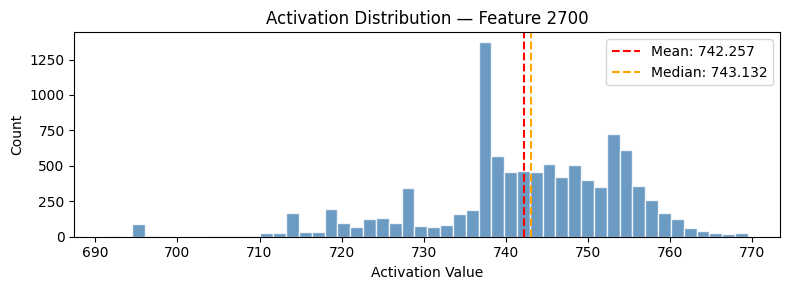


--- Co-occurring Features ---


,feature_id,co_occurrence_count,token_ids
0,2591,616,"[6385, 43462, 261, 47696, 18257, 9171, 5990, 2..."
1,580,616,"[23675, 4826, 24206, 28054, 4863, 28718, 7575,..."
2,1893,616,"[46667, 2202, 19618, 42349, 18165, 40640, 2207..."
3,418,616,"[259, 14282, 67, 12832, 19106, 42369, 48081, 4..."
4,1968,616,"[5962, 39841, 19895, 17798, 26705, 27991, 1295..."
...,...,...,...
1016,293,1,[43566]
1017,2197,1,[2202]
1018,316,1,[64]
1019,1000,1,[259]



--- Token Type Breakdown ---
  pos: {'PROPN': 332, 'NOUN': 253, 'X': 110, 'VERB': 70, 'ADJ': 68, 'NUM': 39, 'ADV': 31, 'PUNCT': 24, 'ADP': 23, 'DET': 15, 'PRON': 12, 'AUX': 9, 'SPACE': 9, 'SCONJ': 2, 'INTJ': 2, 'CCONJ': 1}
  ner: {'O': 753, 'ORG': 101, 'PERSON': 63, 'DATE': 26, 'GPE': 14, 'CARDINAL': 14, 'NORP': 10, 'PRODUCT': 6, 'WORK_OF_ART': 4, 'EVENT': 2, 'TIME': 2, 'LAW': 2, 'LOC': 2, 'QUANTITY': 1}
  is_stop: {False: 953, True: 47}
  is_punct: {False: 985, True: 15}
  dep: {'compound': 258, '': 103, 'ROOT': 86, 'nsubj': 69, 'appos': 64, 'amod': 57, 'nmod': 51, 'punct': 45, 'dobj': 39, 'pobj': 33, 'nummod': 32, 'advmod': 29, 'npadvmod': 29, 'prep': 23, 'dep': 16, 'det': 15, 'conj': 9, 'advcl': 6, 'ccomp': 6, 'aux': 5, 'attr': 5, 'acl': 4, 'poss': 3, 'acomp': 3, 'dative': 2, 'xcomp': 2, 'preconj': 1, 'pcomp': 1, 'prt': 1, 'relcl': 1, 'parataxis': 1, 'cc': 1}
  subword_position: {'word_medial': 1000}
  is_numeric: {False: 998, True: 2}
  is_upper: {False: 1000}
  is_title: {True: 9

In [7]:
inspect_idx = 0  # 0 to len(batch_results)-1

r = batch_results[inspect_idx]
print(f"[{inspect_idx + 1}/{len(batch_results)}]")
display_feature_result(r, show_histogram=True)

# Aggregate Analysis

### Monosemanticity Rate

In [8]:
polysemantic_count = sum(
    1 for r in batch_results if "POLYSEMANTIC" in r["llm_label"].upper()
)
total_count = len(batch_results)
monosemantic_rate = 1 - (polysemantic_count / total_count)

print(f"Monosemanticity Rate: {monosemantic_rate:.1%}")
print(f"  Polysemantic: {polysemantic_count}/{total_count}")
print(f"  Monosemantic: {total_count - polysemantic_count}/{total_count}")

for group in ["top-k", "bottom-k"]:
    group_results = [r for r in batch_results if r["group"] == group]
    group_poly = sum(1 for r in group_results if "POLYSEMANTIC" in r["llm_label"].upper())
    print(f"  {group}: {len(group_results) - group_poly}/{len(group_results)} monosemantic "
          f"({1 - group_poly / len(group_results):.1%})")

Monosemanticity Rate: 82.0%
  Polysemantic: 9/50
  Monosemantic: 41/50
  top-k: 23/25 monosemantic (92.0%)
  bottom-k: 18/25 monosemantic (72.0%)


### Feature Density

,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens,feature_density
0,2700,top-k,Sentence-initial During/Under fragments,742.257019,743.131714,12.321902,1873,5.757820e-05
1,159,top-k,Article headline question starts,656.015808,656.063293,13.740405,1873,5.758396e-05
2,2292,top-k,article/media section headers,574.558167,576.763000,14.457967,1874,5.758972e-05
3,1039,top-k,Reuters/AP-style WASHINGTON dateline,505.427704,506.307526,7.958144,1873,5.757820e-05
4,2591,top-k,Start of news bylines/headlines,497.866699,502.099640,20.996035,1874,5.758396e-05
5,2657,top-k,Preposition “barring” meaning except for,10.804600,10.918356,1.798152,1,6.909384e-08
6,365,top-k,POLYSEMANTIC,8.622722,8.016462,1.852058,8,5.757820e-08
7,2617,top-k,Apostrophe encoding errors,8.256230,8.028912,1.603353,4,6.909384e-08
8,30,top-k,“so much” phrase,8.046525,8.074970,0.866023,1,7.485166e-08
9,149,top-k,“h/t” hat-tip attribution,7.645664,7.682373,0.649934,1,6.909384e-08


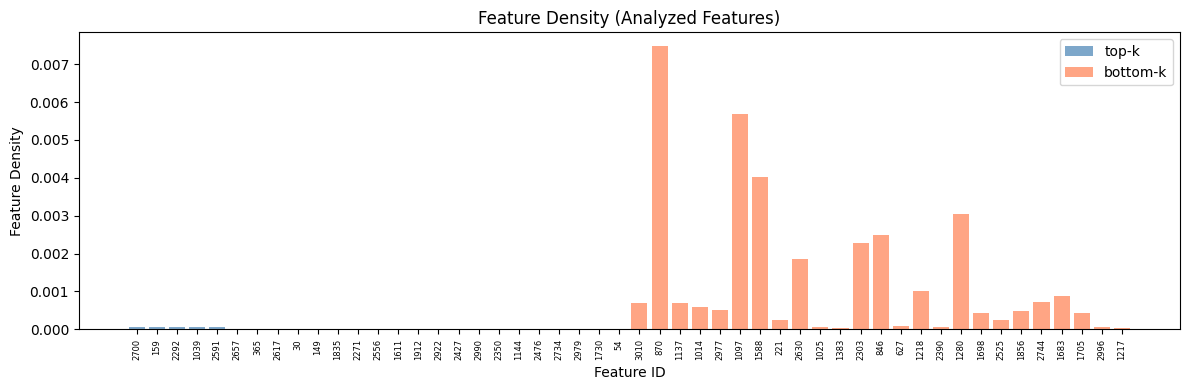

In [9]:
density_df = feature_analyzer.get_feature_density(table_name)

batch_summary_with_density = batch_summary_df.merge(density_df, on="feature_id", how="left")
display(batch_summary_with_density)

fig, ax = plt.subplots(figsize=(12, 4))
for group, color in [("top-k", "steelblue"), ("bottom-k", "coral")]:
    group_data = batch_summary_with_density[batch_summary_with_density["group"] == group]
    ax.bar(
        group_data["feature_id"].astype(str),
        group_data["feature_density"],
        color=color, alpha=0.7, label=group
    )
ax.set_xlabel("Feature ID")
ax.set_ylabel("Feature Density")
ax.set_title("Feature Density (Analyzed Features)")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

### Pairwise Feature Similarity

Computing similarity matrix:   0%|          | 0/50 [00:00<?, ?it/s]

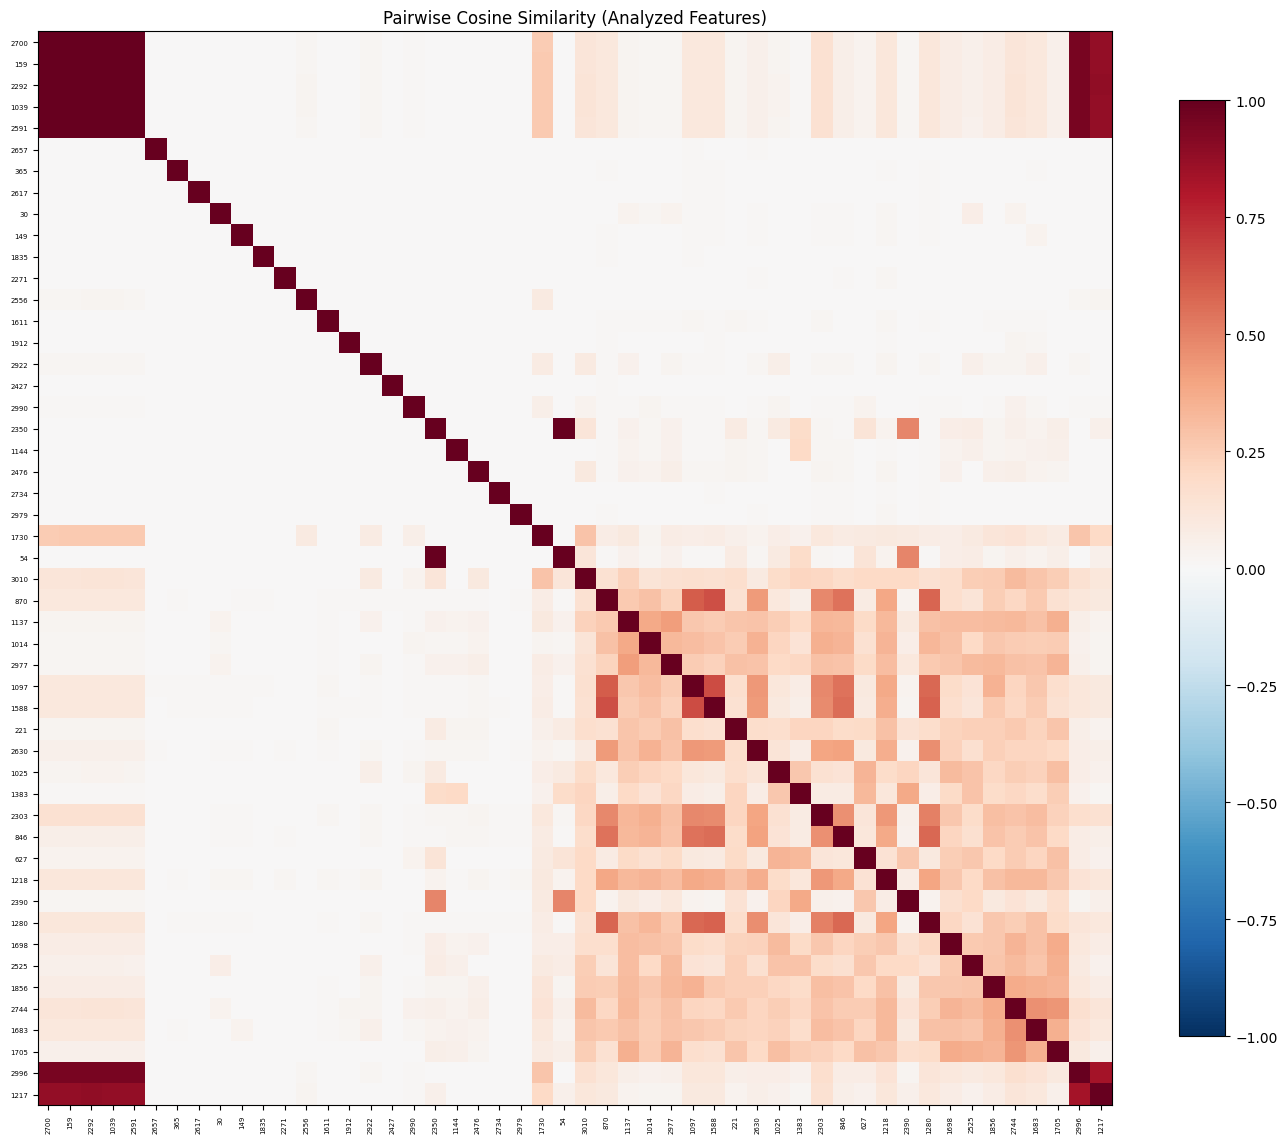

In [10]:
analyzed_feature_ids = [r["feature_id"] for r in batch_results]
n = len(analyzed_feature_ids)

sim_matrix = np.eye(n)
for i in tqdm(range(n), desc="Computing similarity matrix"):
    for j in range(i + 1, n):
        sim = feature_analyzer.feature_similarity_cosine_similarity(
            table_name, int(analyzed_feature_ids[i]), int(analyzed_feature_ids[j])
        )
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
labels = [str(fid) for fid in analyzed_feature_ids]
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_yticklabels(labels, fontsize=5)
ax.set_title("Pairwise Cosine Similarity (Analyzed Features)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Activation Distribution Grid

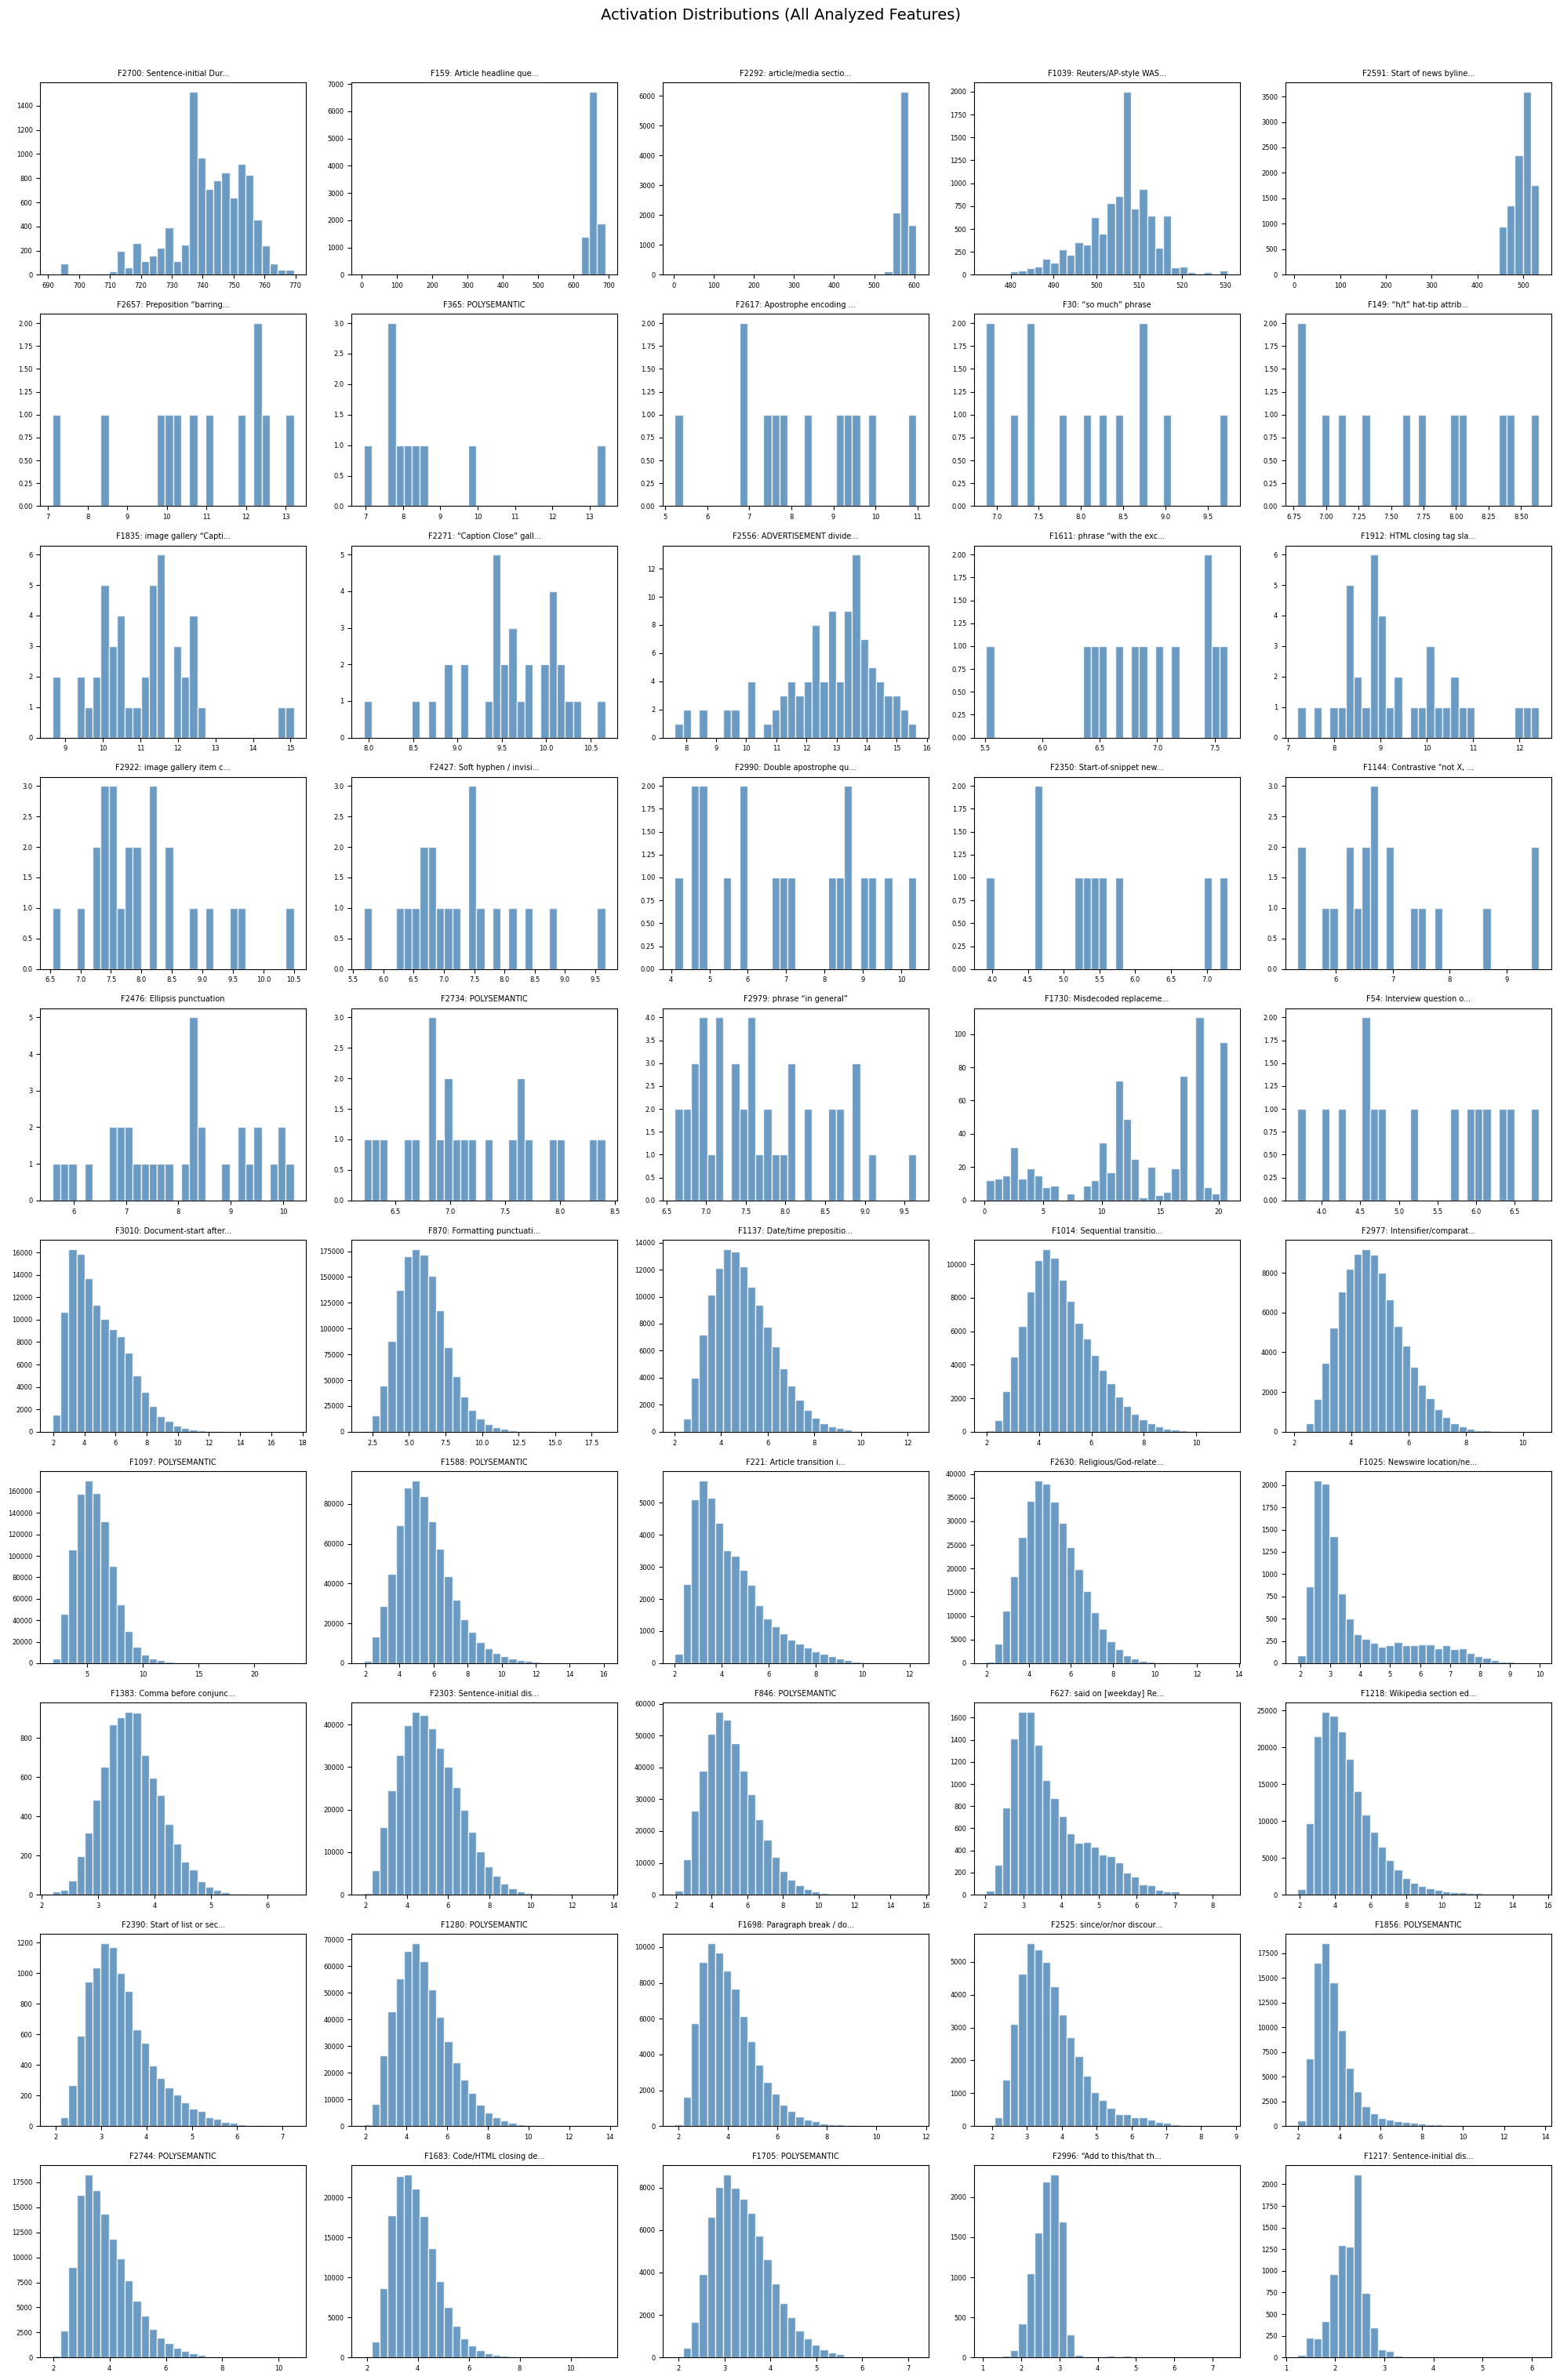

In [11]:
n_cols = 5
n_rows = (len(batch_results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, r in enumerate(batch_results):
    ax = axes[idx]
    ax.hist(r["raw_activations"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    label_short = r["llm_label"][:20] + "..." if len(r["llm_label"]) > 20 else r["llm_label"]
    ax.set_title(f"F{r['feature_id']}: {label_short}", fontsize=7)
    ax.tick_params(labelsize=6)

for idx in range(len(batch_results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Activation Distributions (All Analyzed Features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Dead Feature Proportions

In [12]:
dead_df = feature_analyzer.get_dead_features()
dead_df

alive_features_4x_0.01.json: 0.00B [00:00, ?B/s]

,feature_id
0,0
1,31
2,37
3,50
4,59
...,...
397,3026
398,3034
399,3039
400,3058


In [13]:
dead_proportion = len(dead_df)/(expansion_factor*gpt_dim)
dead_proportion

0.130859375